In [23]:
import pandas as pd


data = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')



data.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [24]:
print("\nMissing values per column:\n", df.isnull().sum())


data.dropna(subset=['Sales', 'Profit', 'Order Date'], inplace=True)



Missing values per column:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [25]:
print("Duplicates before:", df.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicates after:", df.duplicated().sum())


Duplicates before: 0
Duplicates after: 0


In [26]:
data['Order Date'] = pd.to_datetime(df['Order Date'])
data['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [27]:
Q1 = data['Sales'].quantile(0.25)
Q3 = data['Sales'].quantile(0.75)
IQR = Q3 - Q1

data_IQR = data[(data['Sales'] >= Q1 - 1.5*IQR) & (data['Sales'] <= Q3 + 1.5*IQR)]


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipython-input-838036446.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')


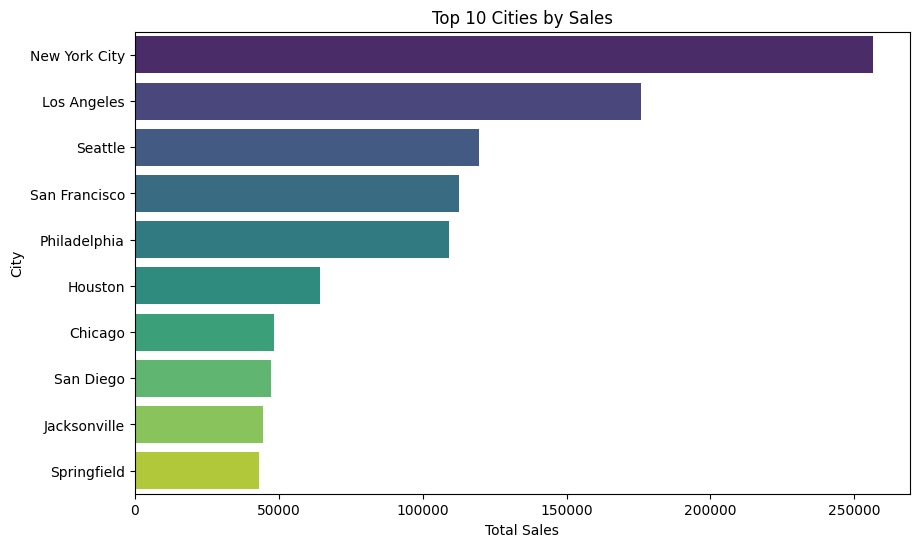

In [28]:
# . Exploratory Data Analysis (EDA)

# -------------------------------
# Top 10 Cities by Total Sales
# -------------------------------
top_cities = data.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 10 Cities by Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')
plt.show()


/tmp/ipython-input-1607836862.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Category', y='Sales', data=data, estimator=sum, ci=None, palette='cool')
/tmp/ipython-input-1607836862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=data, estimator=sum, ci=None, palette='cool')


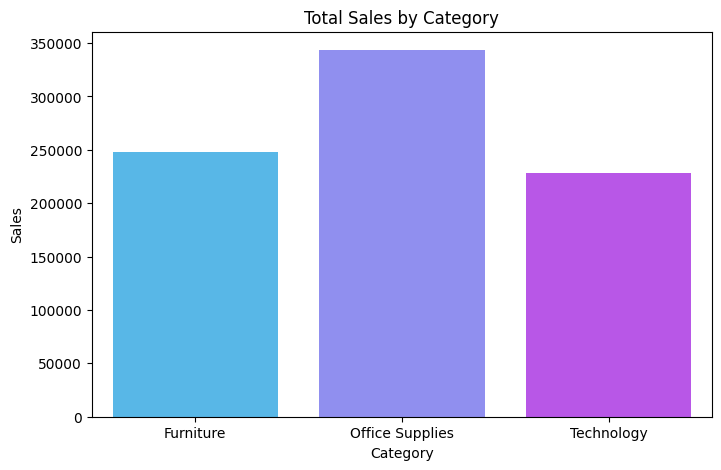

In [9]:

# -------------------------------
# Sales by Category
# -------------------------------
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=data, estimator=sum, ci=None, palette='cool')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.xlabel('Category')
plt.show()

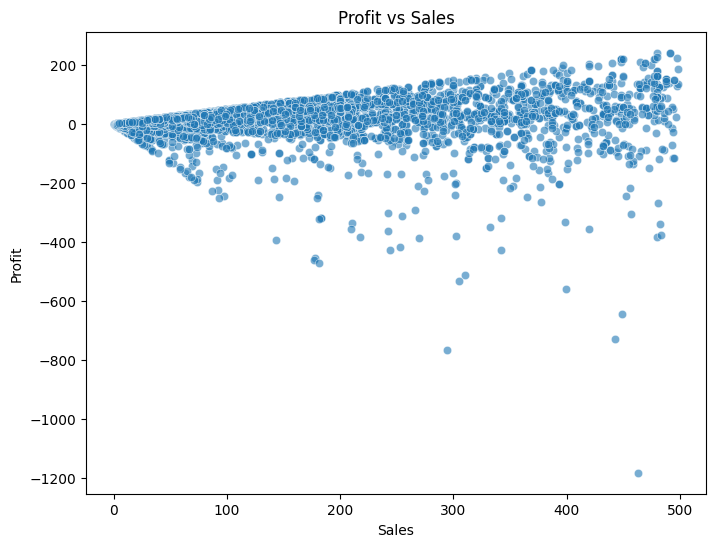

In [10]:
# -------------------------------
# Profit vs Sales Scatter Plot
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='Sales', y='Profit', data=data, alpha=0.6)
plt.title('Profit vs Sales')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

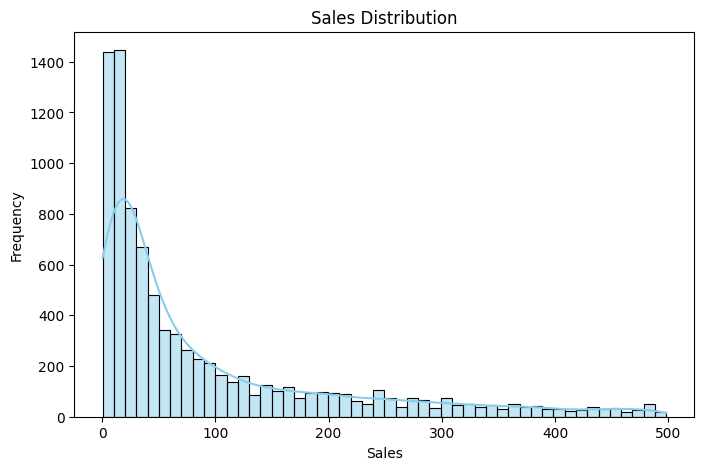

In [11]:
# -------------------------------
# Sales Distribution
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(data['Sales'], bins=50, kde=True, color='skyblue')
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-3889155054.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Sales', data=data, estimator=sum, ci=None, palette='mako')
/tmp/ipython-input-3889155054.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales', data=data, estimator=sum, ci=None, palette='mako')


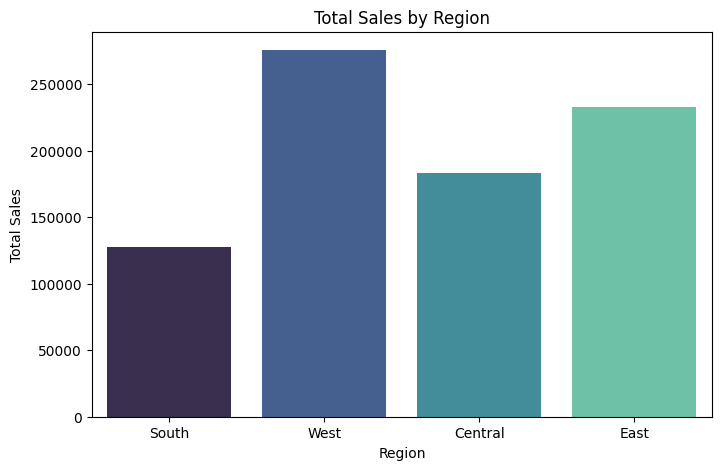

In [12]:
# -------------------------------
# Sales by Region
# -------------------------------
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=data, estimator=sum, ci=None, palette='mako')
plt.title('Total Sales by Region')
plt.ylabel('Total Sales')
plt.xlabel('Region')
plt.show()

/tmp/ipython-input-682998268.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Month'] = data['Order Date'].dt.to_period('M')


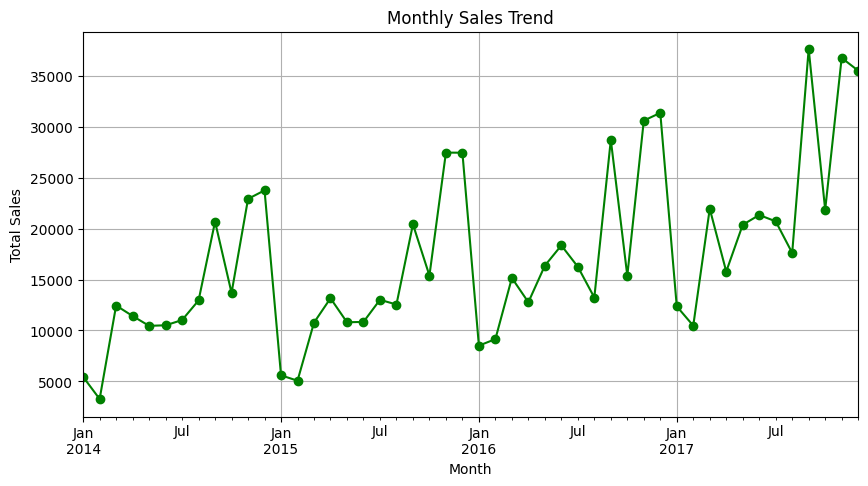

In [13]:
# -------------------------------
# Monthly Sales Trend
# -------------------------------
data['Month'] = data['Order Date'].dt.to_period('M')
monthly_sales = data.groupby('Month')['Sales'].sum()
monthly_sales.plot(kind='line', figsize=(10,5), marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [14]:
print("📊 Descriptive Statistics:")
print(data.describe())

📊 Descriptive Statistics:
            Row ID                     Order Date  \
count  8827.000000                           8827   
mean   5016.375892  2016-05-02 15:45:12.541067264   
min       1.000000            2014-01-03 00:00:00   
25%    2508.500000            2015-05-28 00:00:00   
50%    5028.000000            2016-07-01 00:00:00   
75%    7517.500000            2017-05-15 00:00:00   
max    9994.000000            2017-12-30 00:00:00   
std    2888.406540                            NaN   

                           Ship Date   Postal Code        Sales     Quantity  \
count                           8827   8827.000000  8827.000000  8827.000000   
mean   2016-05-06 14:57:05.036818688  55373.635663    92.864853     3.608587   
min              2014-01-07 00:00:00   1040.000000     0.444000     1.000000   
25%              2015-05-31 00:00:00  23320.000000    15.008000     2.000000   
50%              2016-07-03 00:00:00  59801.000000    40.880000     3.000000   
75%             

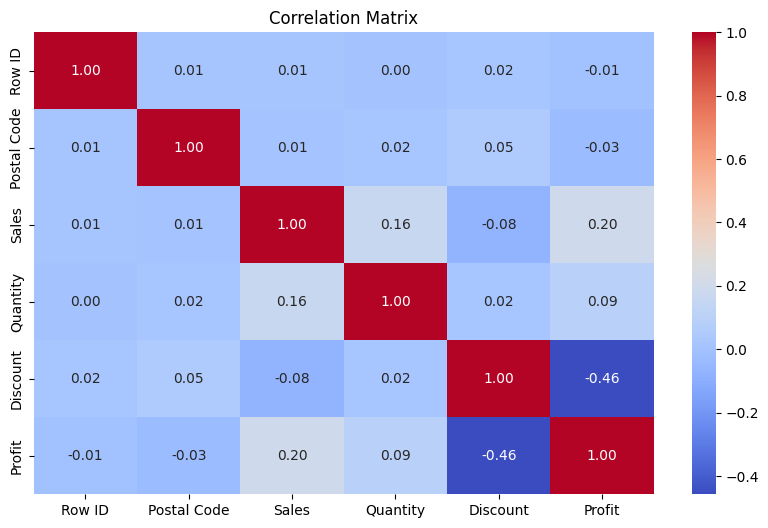

In [15]:

# -------------------------------
# 2️⃣ Correlation Matrix
# -------------------------------
# نحسب الارتباط بين القيم الرقمية فقط
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


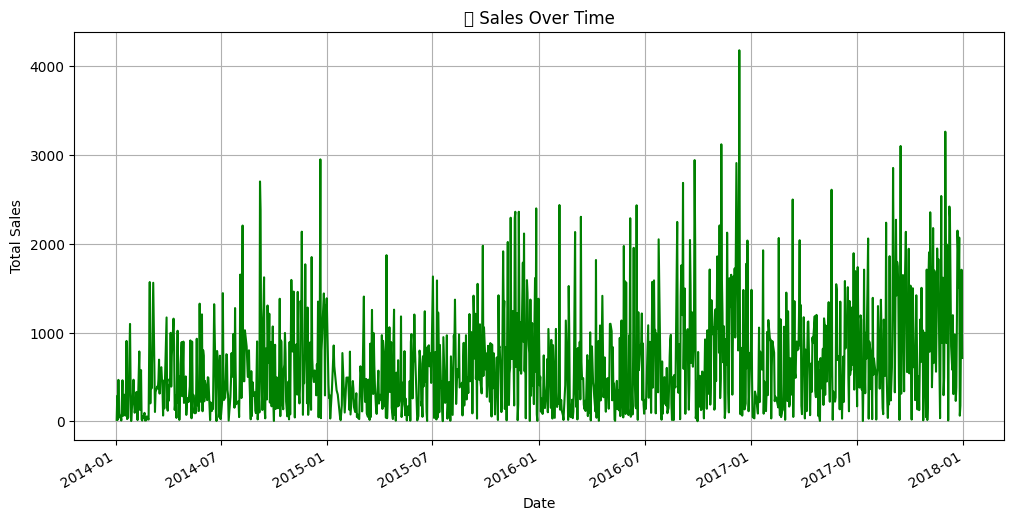

In [16]:
daily_sales = data.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
daily_sales.plot(kind='line', color='green')
plt.title('📈 Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


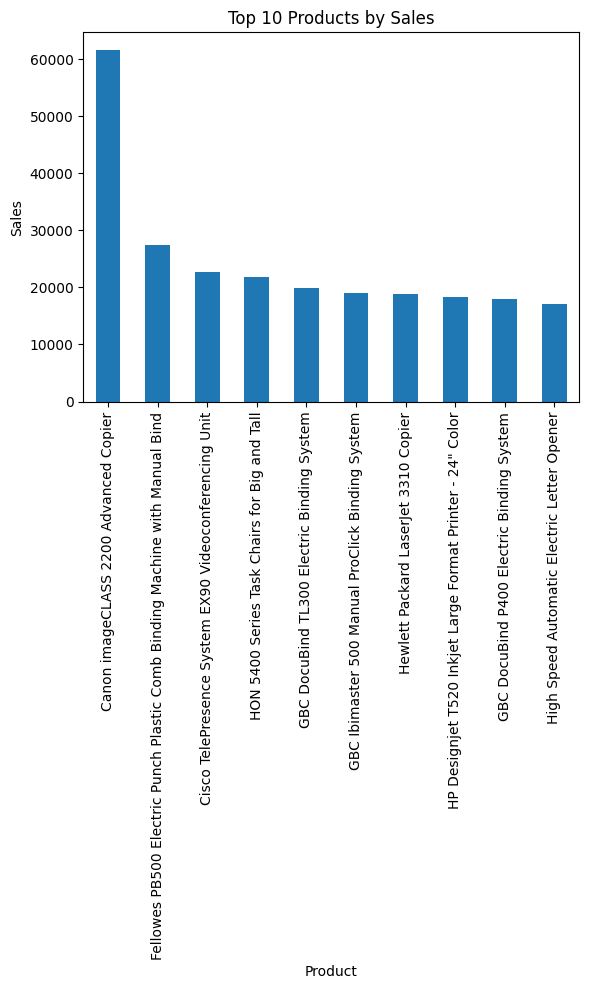

In [21]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.show()

# Regression Analysis → للتنبؤ بالأرباح بناءً على المبيعات والخصم.

🔹 Mean Squared Error: 1268.7995644203318
🔹 R² Score: 0.24216212060038844


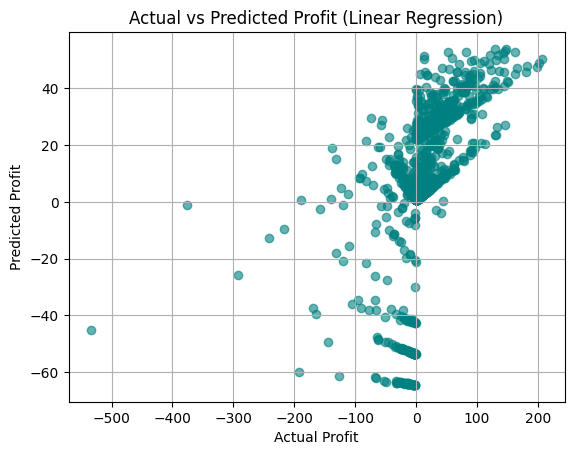

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# نحدد الميزات (المتغيرات المستقلة)
X = data[['Sales', 'Discount']]
y = data['Profit']

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# إنشاء النموذج وتدريبه
model = LinearRegression()
model.fit(X_train, y_train)

# التنبؤ بالقيم
y_pred = model.predict(X_test)

# تقييم النموذج
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("🔹 Mean Squared Error:", mse)
print("🔹 R² Score:", r2)

# رسم العلاقة بين القيم الحقيقية والمتوقعة
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit (Linear Regression)')
plt.grid(True)
plt.show()


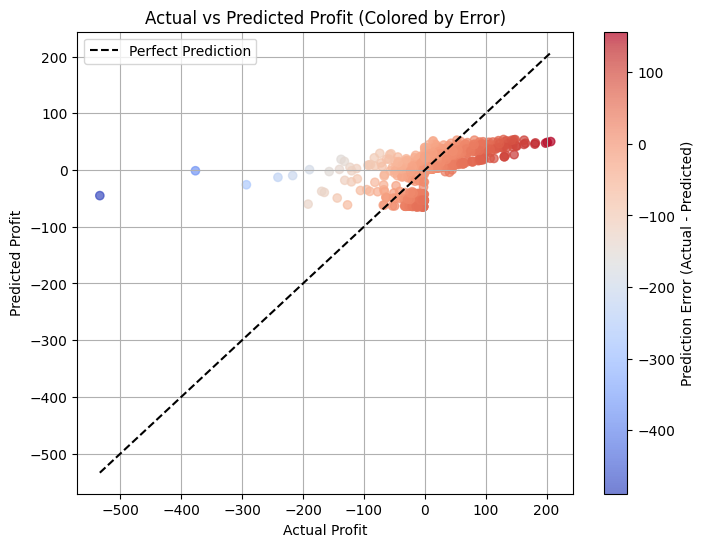

In [29]:

# نحسب الخطأ
error = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, c=error, cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Prediction Error (Actual - Predicted)')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit (Colored by Error)')
plt.grid(True)

# خط مثالي y=x
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.show()

In [30]:
# Export cleaned and analyzed data
data.to_csv('cleaned_superstore.csv', index=False)
print("✅ Cleaned dataset saved as cleaned_superstore.csv")


✅ Cleaned dataset saved as cleaned_superstore.csv
